<div style="background: linear-gradient(135deg, #1B2A4A 0%, #0D7C66 100%); padding: 40px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: white; font-family: Georgia, serif; margin: 0; font-size: 2.4em;">
📡 Notebook 3: Signal Extraction
</h1>
<p style="color: #C9932F; font-size: 1.3em; margin-top: 10px; font-family: Calibri, sans-serif;">
Brazilian E-Commerce (Olist) — Feature Selection, PCA and Dimensionality Reduction
</p>
<p style="color: #B0D0D0; font-size: 0.95em; margin-top: 8px;">
E-Commerce Analytics · MBA Advanced Analytics · 2025-26
</p>
</div>

<div style="background: #FFFFFF; border: 2px solid #0D7C66; padding: 20px 28px; border-radius: 10px; margin: 10px 0 20px 0;">
<h3 style="color: #1B2A4A; margin-top: 0;">Notebook Roadmap</h3>
<ol style="color: #333; font-size: 1.05em; line-height: 1.9;">
<li><strong>Setup and Load Master Table</strong></li>
<li><strong>Build the Modelling Matrix</strong> — Encode, impute, scale</li>
<li><strong>Near-Zero Variance Filter</strong> — Remove no-signal features</li>
<li><strong>Correlation Screening</strong> — Remove redundant pairs</li>
<li><strong>Variance Inflation Factor (VIF)</strong> — Detect multicollinearity</li>
<li><strong>Principal Component Analysis (PCA)</strong> — Scree plot and components</li>
<li><strong>PCA Component Interpretation</strong> — What each component means</li>
<li><strong>Final Reduced Feature Set</strong> — Select features for modelling</li>
<li><strong>Save Modelling-Ready Dataset</strong></li>
</ol>
</div>

> **Input:** olist_master.csv from Session 1
> **Output:** olist_model_ready.csv — clean, encoded, scaled, reduced feature set


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 1: Setup and Load Master Table</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 120,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.titleweight': 'bold', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

NAVY   = '#1B2A4A'
TEAL   = '#0D7C66'
GOLD   = '#C9932F'
CORAL  = '#D95F4B'
PURPLE = '#6B5EA8'
BLUE   = '#3A8FB5'
PALETTE = [NAVY, TEAL, GOLD, CORAL, PURPLE, BLUE]
sns.set_palette(PALETTE)
print("Libraries loaded.")


Libraries loaded.


In [2]:
DATA_DIR = r'C:\Users\DevA\OneDrive\Desktop\All in one - Desktop Files\MBA\Q8\AI ML\Dataset 3'

master = pd.read_csv(os.path.join(DATA_DIR, 'olist_master.csv'), parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

print(f"Master table: {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"Bad experience rate: {master['bad_experience'].mean():.2%}")
print(f"Columns: {list(master.columns)}")


Master table: 96,478 rows x 34 columns
Bad experience rate: 12.72%
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_city', 'customer_state', 'n_items', 'total_price', 'total_freight', 'avg_price', 'n_unique_sellers', 'n_unique_products', 'total_payment', 'n_payment_methods', 'max_installments', 'payment_type', 'review_score', 'main_category', 'avg_weight_g', 'bad_experience', 'delivery_delay_days', 'actual_delivery_days', 'approval_time_hours', 'is_late', 'freight_ratio', 'total_order_value', 'avg_item_value', 'purchase_hour', 'purchase_dayofweek', 'purchase_month']


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 2: Build the Modelling Matrix</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Encode categoricals, impute nulls, scale numerics</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">Steps in this part</strong><br>
<span style="color: #333;">
1. Select the feature columns for modelling<br>
2. One-hot encode categorical columns (payment_type, main_category, customer_state)<br>
3. Median-impute any remaining nulls<br>
4. Standardise all numeric features (zero mean, unit variance)<br>
5. Keep target (bad_experience) separate — never scale the target
</span>
</div>

In [3]:
# ── Feature columns ──
numeric_cols = [
    'delivery_delay_days', 'actual_delivery_days', 'approval_time_hours',
    'is_late', 'freight_ratio', 'total_order_value', 'avg_item_value',
    'n_items', 'max_installments', 'avg_weight_g', 'n_unique_sellers',
    'purchase_hour', 'purchase_dayofweek', 'purchase_month',
    'n_unique_products', 'total_freight', 'total_price',
]
categorical_cols = ['payment_type', 'main_category', 'customer_state']
target_col = 'bad_experience'

# Keep only columns that exist in master
numeric_cols     = [c for c in numeric_cols     if c in master.columns]
categorical_cols = [c for c in categorical_cols if c in master.columns]

print(f"Numeric features selected     : {len(numeric_cols)}")
print(f"Categorical features to encode: {len(categorical_cols)}")
print(f"Numeric: {numeric_cols}")
print(f"Categorical: {categorical_cols}")


Numeric features selected     : 17
Categorical features to encode: 3
Numeric: ['delivery_delay_days', 'actual_delivery_days', 'approval_time_hours', 'is_late', 'freight_ratio', 'total_order_value', 'avg_item_value', 'n_items', 'max_installments', 'avg_weight_g', 'n_unique_sellers', 'purchase_hour', 'purchase_dayofweek', 'purchase_month', 'n_unique_products', 'total_freight', 'total_price']
Categorical: ['payment_type', 'main_category', 'customer_state']


In [4]:
# ── Build base dataframe ──
model_df = master[numeric_cols + categorical_cols + [target_col]].copy()

print(f"Before encoding: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns")
null_counts = model_df.isnull().sum()
null_counts = null_counts[null_counts > 0]
if len(null_counts) > 0:
    print("Null counts before imputation:")
    print(null_counts.to_string())
else:
    print("No nulls found.")


Before encoding: 96,478 rows x 21 columns
Null counts before imputation:
delivery_delay_days      8
actual_delivery_days     8
approval_time_hours     14
max_installments         1
avg_weight_g            16
payment_type             1


In [5]:
# ── Median-impute numeric nulls ──
for col in numeric_cols:
    if model_df[col].isnull().any():
        median_val = model_df[col].median()
        model_df[col] = model_df[col].fillna(median_val)
        print(f"  Imputed {col} with median = {median_val:.2f}")

# ── One-hot encode categoricals (drop_first to avoid dummy trap) ──
model_encoded = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

# Convert bool columns to int
bool_cols = model_encoded.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    model_encoded[bool_cols] = model_encoded[bool_cols].astype(int)

print(f"After encoding: {model_encoded.shape[0]:,} rows x {model_encoded.shape[1]} columns")
print(f"Dummy columns added: {model_encoded.shape[1] - len(numeric_cols) - 1}")


  Imputed delivery_delay_days with median = -11.90
  Imputed actual_delivery_days with median = 10.20
  Imputed approval_time_hours with median = 0.30
  Imputed max_installments with median = 2.00
  Imputed avg_weight_g with median = 700.00
After encoding: 96,478 rows x 118 columns
Dummy columns added: 100


In [6]:
# ── Separate features from target ──
feature_cols = [c for c in model_encoded.columns if c != target_col]
X = model_encoded[feature_cols].copy()
y = model_encoded[target_col].copy()

# ── Standardise ──
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_arr, columns=feature_cols, index=X.index)

print(f"Feature matrix : {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print(f"Target         : {y.shape[0]:,} rows  |  bad exp rate: {y.mean():.2%}")
print(f"Mean (first 3 cols, should be ~0): {X_scaled.iloc[:, :3].mean().round(6).to_dict()}")


Feature matrix : 96,478 rows x 117 features
Target         : 96,478 rows  |  bad exp rate: 12.72%
Mean (first 3 cols, should be ~0): {'delivery_delay_days': -0.0, 'actual_delivery_days': 0.0, 'approval_time_hours': -0.0}


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 3: Near-Zero Variance Filter</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Remove features that carry almost no information</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">Why remove low-variance features?</strong><br>
<span style="color: #333;">
A feature that is the same value for 95% or more of rows tells the model almost nothing.
It adds noise and can hurt generalisation. We flag features where the most common value
appears in more than 95% of rows.
</span>
</div>

In [7]:
NZV_THRESHOLD = 0.95

nzv_report = []
for col in X.columns:
    freq_counts = X[col].value_counts(normalize=True)
    top_freq = freq_counts.iloc[0] if len(freq_counts) > 0 else 1.0
    variance  = X[col].var()
    nzv_report.append({
        'feature'      : col,
        'top_freq'     : round(top_freq, 4),
        'variance'     : round(variance, 4),
        'near_zero_var': top_freq > NZV_THRESHOLD
    })

nzv_df = pd.DataFrame(nzv_report).sort_values('top_freq', ascending=False)
nzv_flagged = nzv_df[nzv_df['near_zero_var']]

print(f"Total features      : {len(X.columns)}")
print(f"NZV flagged (>{NZV_THRESHOLD:.0%}): {len(nzv_flagged)}")
if len(nzv_flagged) > 0:
    print("\nFlagged features:")
    print(nzv_flagged[['feature', 'top_freq', 'variance']].to_string(index=False))
else:
    print("No near-zero variance features found.")


Total features      : 117
NZV flagged (>95%): 89

Flagged features:
                                              feature  top_freq  variance
                  main_category_security_and_services    1.0000    0.0000
              main_category_fashion_childrens_clothes    0.9999    0.0001
                      main_category_cds_dvds_musicals    0.9999    0.0001
                             main_category_la_cuisine    0.9999    0.0001
                          main_category_fashion_sport    0.9998    0.0002
                  main_category_arts_and_craftmanship    0.9998    0.0002
                         main_category_home_comfort_2    0.9998    0.0002
                                main_category_flowers    0.9997    0.0003
                    main_category_diapers_and_hygiene    0.9997    0.0003
                 main_category_fashio_female_clothing    0.9996    0.0004
      main_category_furniture_mattress_and_upholstery    0.9996    0.0004
                         main_category_party

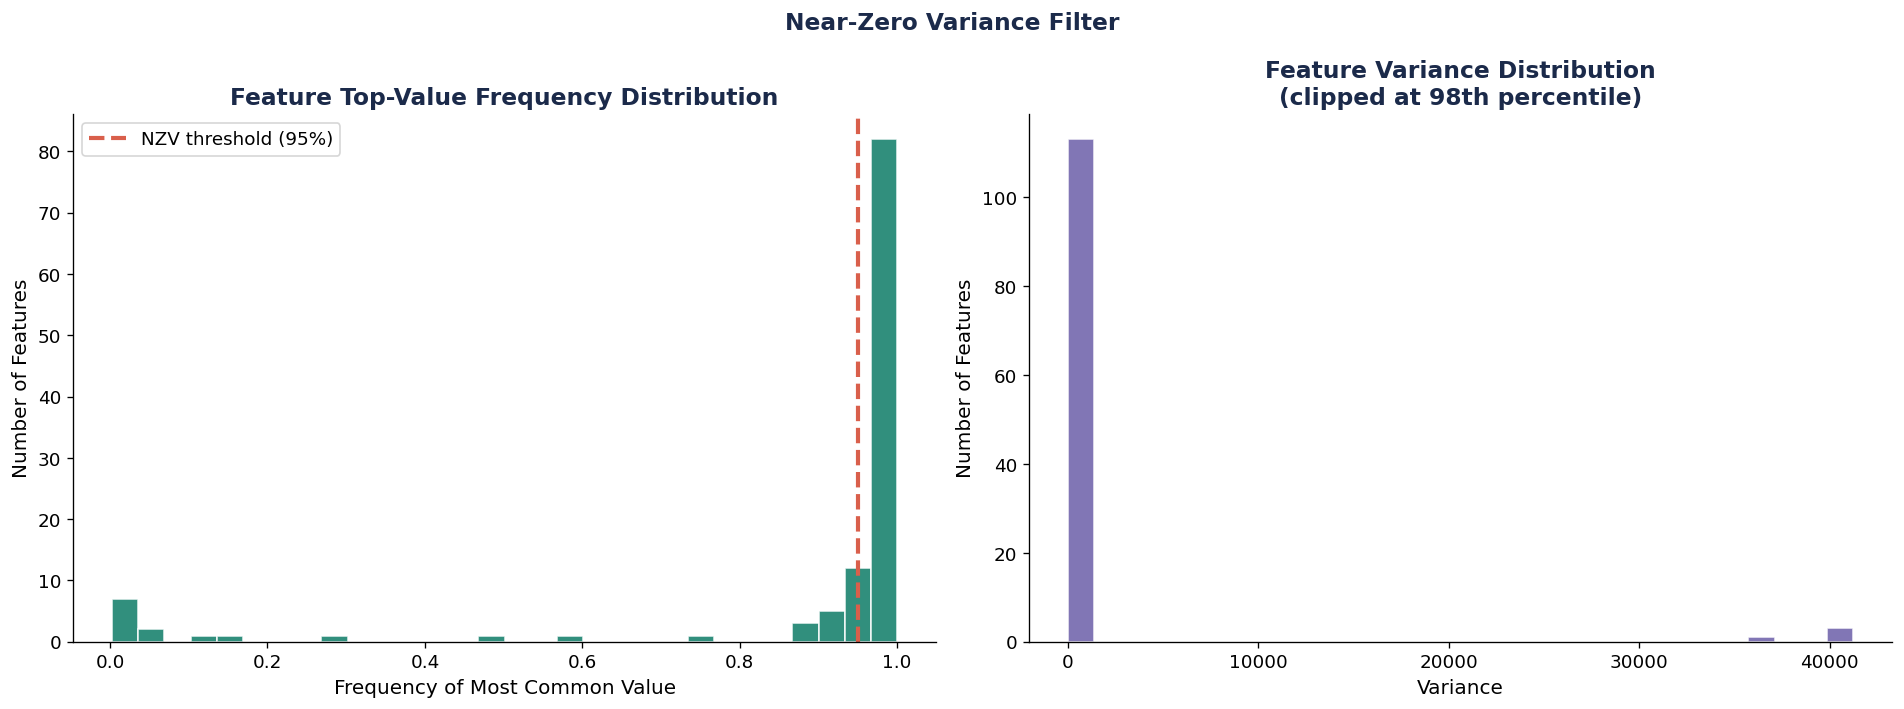

Features after NZV filter: 28  (dropped 89)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: top freq distribution
ax = axes[0]
ax.hist(nzv_df['top_freq'], bins=30, color=TEAL, edgecolor='white', alpha=0.85)
ax.axvline(NZV_THRESHOLD, color=CORAL, linewidth=2.5, linestyle='--',
           label=f'NZV threshold ({NZV_THRESHOLD:.0%})')
ax.set_title('Feature Top-Value Frequency Distribution', color=NAVY, fontweight='bold')
ax.set_xlabel('Frequency of Most Common Value')
ax.set_ylabel('Number of Features')
ax.legend()

# Plot 2: variance distribution
ax = axes[1]
p98 = nzv_df['variance'].quantile(0.98)
var_clipped = nzv_df['variance'].clip(upper=p98)
ax.hist(var_clipped, bins=30, color=PURPLE, edgecolor='white', alpha=0.85)
ax.set_title('Feature Variance Distribution\n(clipped at 98th percentile)',
             color=NAVY, fontweight='bold')
ax.set_xlabel('Variance')
ax.set_ylabel('Number of Features')

plt.suptitle('Near-Zero Variance Filter', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Drop flagged ──
cols_to_drop_nzv = nzv_flagged['feature'].tolist()
X_filtered = X_scaled.drop(columns=cols_to_drop_nzv)
print(f"Features after NZV filter: {X_filtered.shape[1]}  (dropped {len(cols_to_drop_nzv)})")


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 4: Correlation Screening</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Remove one from each highly correlated pair to reduce redundancy</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">Why does redundancy matter?</strong><br>
<span style="color: #333;">
If two features are almost perfectly correlated (e.g. total_price and total_order_value),
they carry the same information. Keeping both inflates coefficient variance and makes
model interpretation harder. We remove one from each pair above a 0.90 threshold.
</span>
</div>

In [9]:
CORR_THRESHOLD = 0.90

corr_matrix_abs = X_filtered.corr().abs()
upper_tri = corr_matrix_abs.where(
    np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_tri.columns:
    partners = upper_tri.index[upper_tri[col] > CORR_THRESHOLD].tolist()
    for partner in partners:
        high_corr_pairs.append({
            'feature_A'     : partner,
            'feature_B'     : col,
            'correlation'   : round(corr_matrix_abs.loc[partner, col], 4),
            'drop_candidate': col
        })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)

print(f"Correlation threshold : {CORR_THRESHOLD}")
print(f"High-correlation pairs found: {len(high_corr_df)}")
if len(high_corr_df) > 0:
    print("\nPairs to address:")
    print(high_corr_df[['feature_A', 'feature_B', 'correlation', 'drop_candidate']].to_string(index=False))
else:
    print("No pairs above threshold found.")


Correlation threshold : 0.9
High-correlation pairs found: 3

Pairs to address:
        feature_A      feature_B  correlation drop_candidate
total_order_value    total_price       0.9960    total_price
   avg_item_value    total_price       0.9330    total_price
total_order_value avg_item_value       0.9209 avg_item_value


Features after correlation filter: 26  (dropped 2)
Dropped: ['avg_item_value', 'total_price']


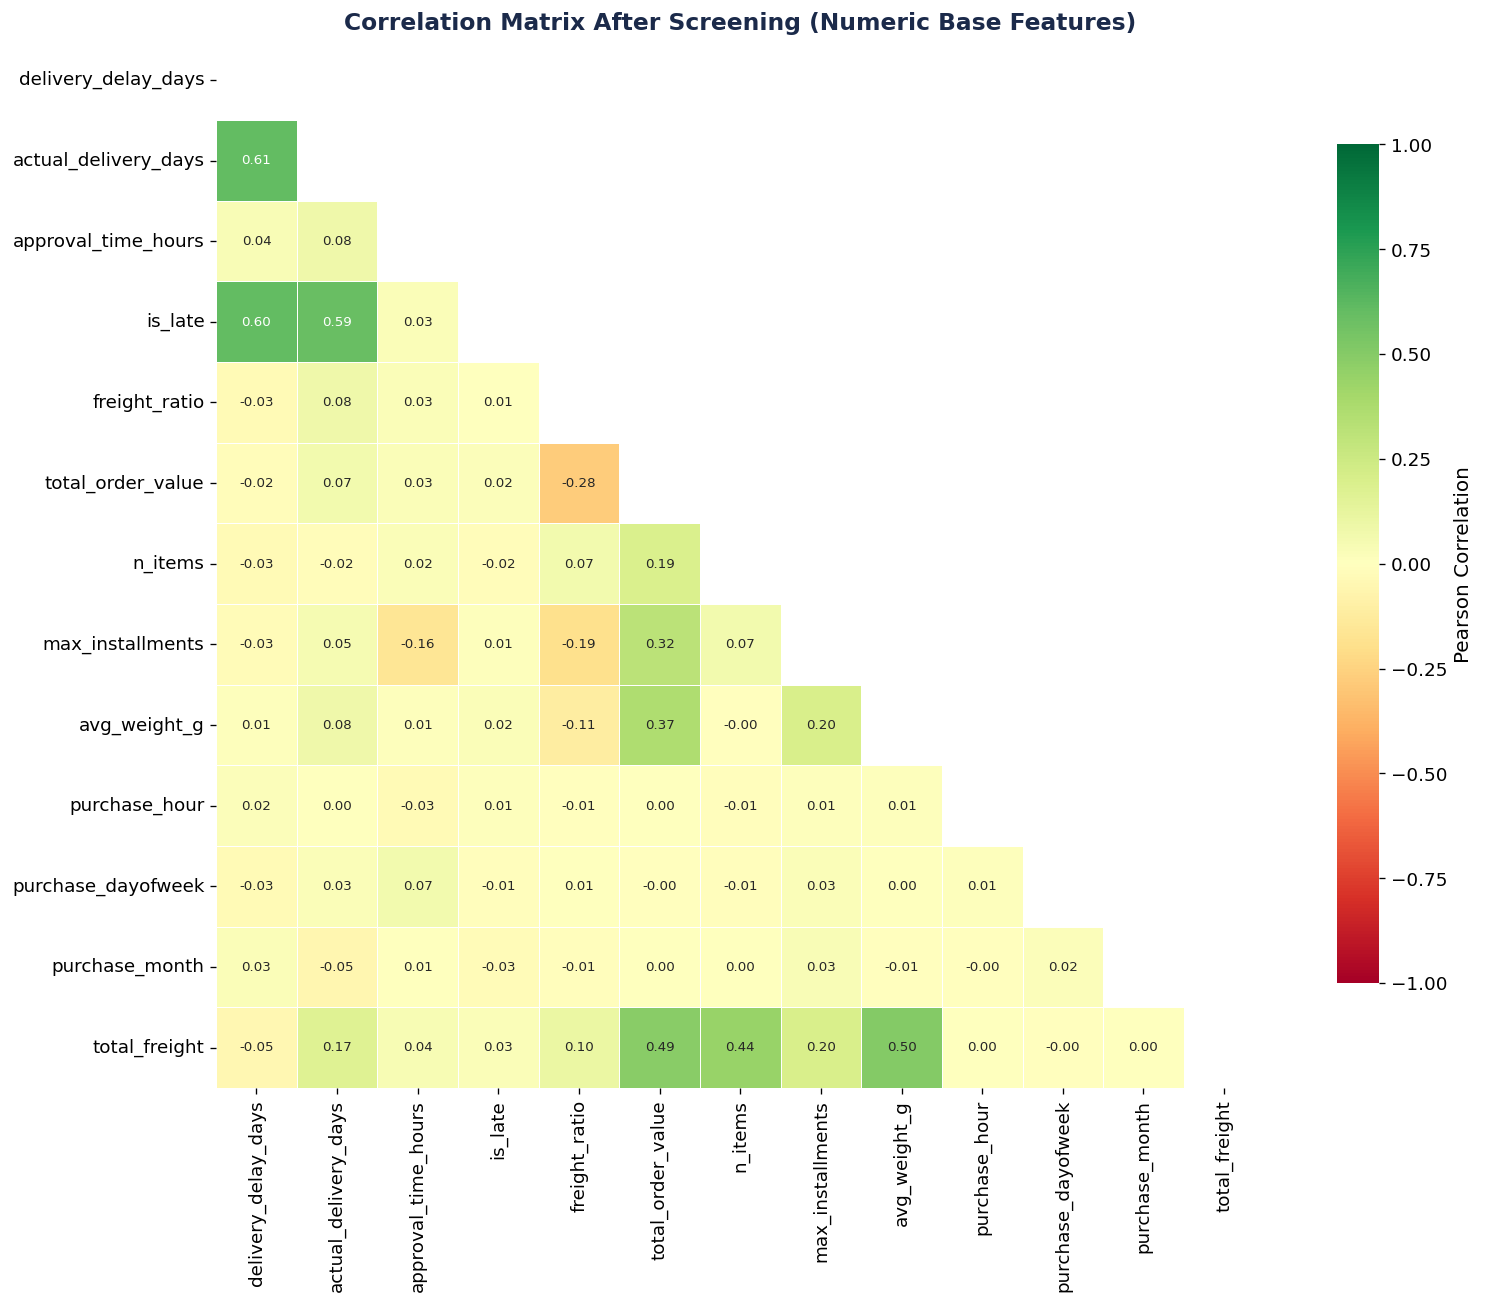

In [10]:
cols_to_drop_corr = list(set(high_corr_df['drop_candidate'].tolist())) if len(high_corr_df) > 0 else []
X_filtered2 = X_filtered.drop(columns=cols_to_drop_corr)

print(f"Features after correlation filter: {X_filtered2.shape[1]}  (dropped {len(cols_to_drop_corr)})")
if cols_to_drop_corr:
    print(f"Dropped: {cols_to_drop_corr}")

# ── Remaining correlation heatmap (numeric base features only) ──
base_cols = [c for c in X_filtered2.columns
             if not any(c.startswith(cat + '_') for cat in categorical_cols)]
base_cols = base_cols[:20]

if len(base_cols) > 1:
    fig, ax = plt.subplots(figsize=(14, 11))
    cm = X_filtered2[base_cols].corr()
    mask = np.triu(np.ones_like(cm, dtype=bool))
    sns.heatmap(cm, mask=mask, ax=ax, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                linewidths=0.5, square=True,
                cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'})
    ax.set_title('Correlation Matrix After Screening (Numeric Base Features)',
                 color=NAVY, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 5: Variance Inflation Factor (VIF)</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Detecting multicollinearity beyond pairwise correlation</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">What is VIF?</strong><br>
<span style="color: #333;">
VIF measures how much a feature's variance is inflated due to correlation with all other features combined.
Rule of thumb: VIF over 10 = serious multicollinearity. VIF over 5 = moderate. VIF under 5 = acceptable.
</span>
</div>

In [11]:
# VIF on numeric base features only
vif_cols = [c for c in X_filtered2.columns
            if not any(c.startswith(cat + '_') for cat in categorical_cols)]

vif_df = pd.DataFrame()
if len(vif_cols) > 1:
    X_vif = X_filtered2[vif_cols].dropna()
    vif_records = []
    for i, col in enumerate(vif_cols):
        try:
            vif_val = variance_inflation_factor(X_vif.values, i)
        except Exception:
            vif_val = np.nan
        vif_records.append({'feature': col, 'VIF': round(float(vif_val), 2)})

    vif_df = pd.DataFrame(vif_records).sort_values('VIF', ascending=False)

    print("VIF Results:")
    print("-" * 45)
    for _, row in vif_df.iterrows():
        flag = '  <<< HIGH'     if row['VIF'] > 10 else                '  < moderate'   if row['VIF'] > 5  else ''
        vif_str = f"{row['VIF']:.2f}" if not np.isnan(row['VIF']) else 'NaN'
        print(f"  {row['feature']:<28} VIF = {vif_str:>7}{flag}")
else:
    print("Not enough numeric columns for VIF.")


VIF Results:
---------------------------------------------
  total_freight                VIF =    2.35
  actual_delivery_days         VIF =    2.02
  delivery_delay_days          VIF =    1.97
  is_late                      VIF =    1.80
  total_order_value            VIF =    1.61
  avg_weight_g                 VIF =    1.54
  n_items                      VIF =    1.38
  freight_ratio                VIF =    1.23
  max_installments             VIF =    1.19
  approval_time_hours          VIF =    1.05
  purchase_dayofweek           VIF =    1.01
  purchase_month               VIF =    1.01
  purchase_hour                VIF =    1.00


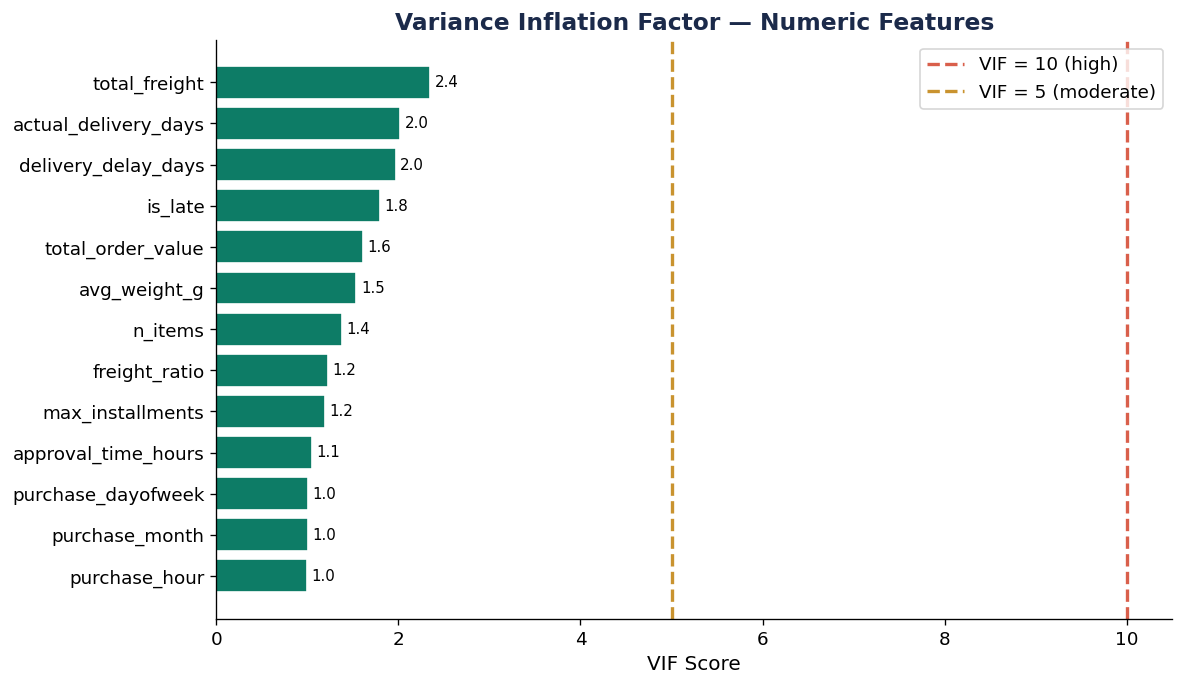

In [12]:
if len(vif_df) > 0:
    vif_plot = vif_df.dropna(subset=['VIF'])
    fig, ax = plt.subplots(figsize=(10, max(5, len(vif_plot) * 0.45)))
    colors = [CORAL if v > 10 else GOLD if v > 5 else TEAL for v in vif_plot['VIF']]
    bars = ax.barh(vif_plot['feature'][::-1], vif_plot['VIF'][::-1],
                   color=list(reversed(colors)), edgecolor='white')
    ax.axvline(10, color=CORAL, linewidth=2, linestyle='--', label='VIF = 10 (high)')
    ax.axvline(5,  color=GOLD,  linewidth=2, linestyle='--', label='VIF = 5 (moderate)')
    ax.set_title('Variance Inflation Factor — Numeric Features',
                 color=NAVY, fontweight='bold')
    ax.set_xlabel('VIF Score')
    ax.legend()
    for bar, val in zip(bars, vif_plot['VIF'][::-1]):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 6: Principal Component Analysis (PCA)</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Compress features while retaining maximum variance</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">What PCA does</strong><br>
<span style="color: #333;">
PCA finds new axes (components) that capture the most variance in the data, combining correlated
features into composite signals. We run PCA on all filtered features, then use the scree plot
to decide how many components to retain.
</span>
</div>

In [13]:
X_pca_input = X_filtered2.fillna(0)

pca_full = PCA(random_state=42)
pca_full.fit(X_pca_input)

explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

n_for_80 = int(np.argmax(cumulative_var >= 0.80)) + 1
n_for_90 = int(np.argmax(cumulative_var >= 0.90)) + 1
n_for_95 = int(np.argmax(cumulative_var >= 0.95)) + 1

print(f"Total features entering PCA : {X_pca_input.shape[1]}")
print(f"Components to explain 80%   : {n_for_80}")
print(f"Components to explain 90%   : {n_for_90}")
print(f"Components to explain 95%   : {n_for_95}")
print(f"\nVariance explained by first 10 components:")
for i, ev in enumerate(explained_var[:10]):
    bar = 'X' * int(ev * 80)
    print(f"  PC{i+1:>2}  {ev:.4f}  ({ev*100:.1f}%)  cumulative: {cumulative_var[i]*100:.1f}%  {bar}")


Total features entering PCA : 26
Components to explain 80%   : 16
Components to explain 90%   : 20
Components to explain 95%   : 22

Variance explained by first 10 components:
  PC 1  0.0924  (9.2%)  cumulative: 9.2%  XXXXXXX
  PC 2  0.0845  (8.5%)  cumulative: 17.7%  XXXXXX
  PC 3  0.0665  (6.6%)  cumulative: 24.3%  XXXXX
  PC 4  0.0577  (5.8%)  cumulative: 30.1%  XXXX
  PC 5  0.0488  (4.9%)  cumulative: 35.0%  XXX
  PC 6  0.0439  (4.4%)  cumulative: 39.4%  XXX
  PC 7  0.0434  (4.3%)  cumulative: 43.7%  XXX
  PC 8  0.0428  (4.3%)  cumulative: 48.0%  XXX
  PC 9  0.0423  (4.2%)  cumulative: 52.2%  XXX
  PC10  0.0420  (4.2%)  cumulative: 56.4%  XXX


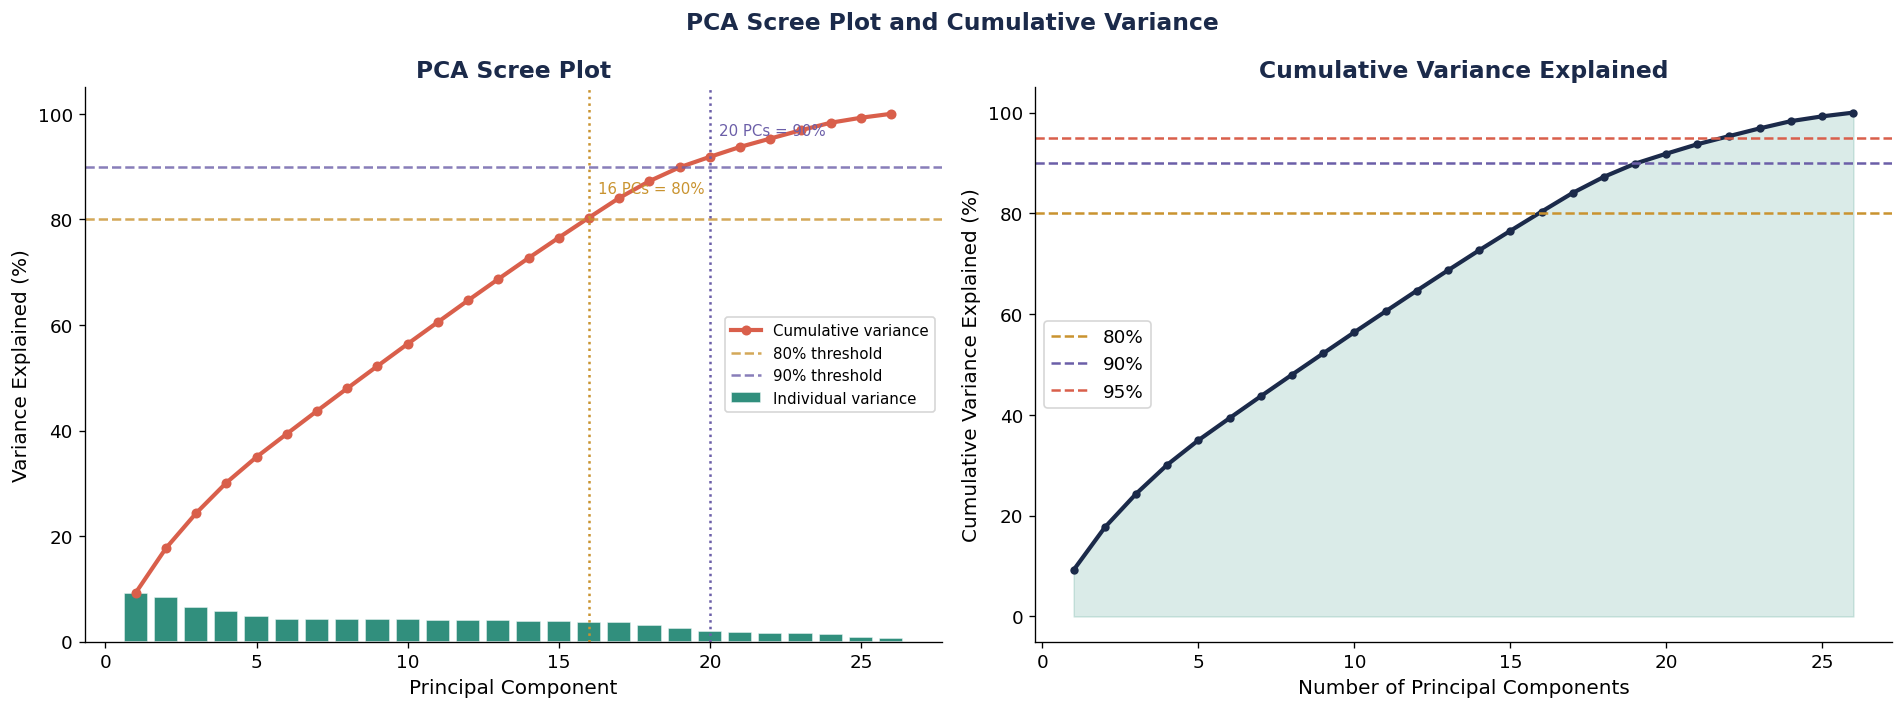

In [14]:
n_show = min(30, len(explained_var))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scree plot
ax = axes[0]
ax.bar(range(1, n_show + 1), explained_var[:n_show] * 100,
       color=TEAL, edgecolor='white', alpha=0.85, label='Individual variance')
ax.plot(range(1, n_show + 1), cumulative_var[:n_show] * 100,
        color=CORAL, linewidth=2.5, marker='o', markersize=5, label='Cumulative variance')
ax.axhline(80, color=GOLD,   linewidth=1.5, linestyle='--', alpha=0.8, label='80% threshold')
ax.axhline(90, color=PURPLE, linewidth=1.5, linestyle='--', alpha=0.8, label='90% threshold')
ax.axvline(n_for_80, color=GOLD,   linewidth=1.5, linestyle=':')
ax.axvline(n_for_90, color=PURPLE, linewidth=1.5, linestyle=':')
ax.set_title('PCA Scree Plot', color=NAVY, fontweight='bold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.legend(fontsize=9)

# Safe annotation placement
y_pos_80 = min(85, cumulative_var[min(n_for_80, len(cumulative_var)-1)] * 100 + 3)
y_pos_90 = min(96, cumulative_var[min(n_for_90, len(cumulative_var)-1)] * 100 + 3)
ax.text(n_for_80 + 0.3, y_pos_80, f'{n_for_80} PCs = 80%', fontsize=9, color=GOLD)
ax.text(n_for_90 + 0.3, y_pos_90, f'{n_for_90} PCs = 90%', fontsize=9, color=PURPLE)

# Plot 2: Cumulative
ax = axes[1]
ax.plot(range(1, n_show + 1), cumulative_var[:n_show] * 100,
        color=NAVY, linewidth=2.5, marker='o', markersize=4)
ax.fill_between(range(1, n_show + 1), cumulative_var[:n_show] * 100,
                alpha=0.15, color=TEAL)
ax.axhline(80, color=GOLD,   linewidth=1.5, linestyle='--', label='80%')
ax.axhline(90, color=PURPLE, linewidth=1.5, linestyle='--', label='90%')
ax.axhline(95, color=CORAL,  linewidth=1.5, linestyle='--', label='95%')
ax.set_title('Cumulative Variance Explained', color=NAVY, fontweight='bold')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.legend()

plt.suptitle('PCA Scree Plot and Cumulative Variance', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 7: PCA Component Interpretation</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">What does each principal component represent?</p>
</div>

In [15]:
N_COMPONENTS = min(5, X_pca_input.shape[1])
pca_interpret = PCA(n_components=N_COMPONENTS, random_state=42)
pca_interpret.fit(X_pca_input)

loadings = pd.DataFrame(
    pca_interpret.components_.T,
    index=X_pca_input.columns,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

print("Top 6 features by absolute loading for each Principal Component:")
print("=" * 65)
for i, pc in enumerate(loadings.columns):
    ev = pca_full.explained_variance_ratio_[i] * 100
    top = loadings[pc].abs().sort_values(ascending=False).head(6)
    print(f"\n{pc}  (explains {ev:.1f}% of variance):")
    for feat, _ in top.items():
        loading_val = loadings.loc[feat, pc]
        direction = '+' if loading_val > 0 else '-'
        bar = 'X' * int(abs(loading_val) * 20)
        print(f"  {direction} {feat:<30} {loading_val:>+.4f}  {bar}")


Top 6 features by absolute loading for each Principal Component:

PC1  (explains 9.2% of variance):
  + actual_delivery_days           +0.4387  XXXXXXXX
  + total_freight                  +0.4210  XXXXXXXX
  + total_order_value              +0.3595  XXXXXXX
  + is_late                        +0.3497  XXXXXX
  + avg_weight_g                   +0.3277  XXXXXX
  + delivery_delay_days            +0.3008  XXXXXX

PC2  (explains 8.5% of variance):
  + delivery_delay_days            +0.4329  XXXXXXXX
  + is_late                        +0.4062  XXXXXXXX
  + actual_delivery_days           +0.3820  XXXXXXX
  - total_order_value              -0.3243  XXXXXX
  - max_installments               -0.3048  XXXXXX
  - total_freight                  -0.2924  XXXXX

PC3  (explains 6.6% of variance):
  + payment_type_credit_card       +0.5302  XXXXXXXXXX
  - approval_time_hours            -0.4746  XXXXXXXXX
  + max_installments               +0.3163  XXXXXX
  - total_freight                  -0.2900  XXXXX

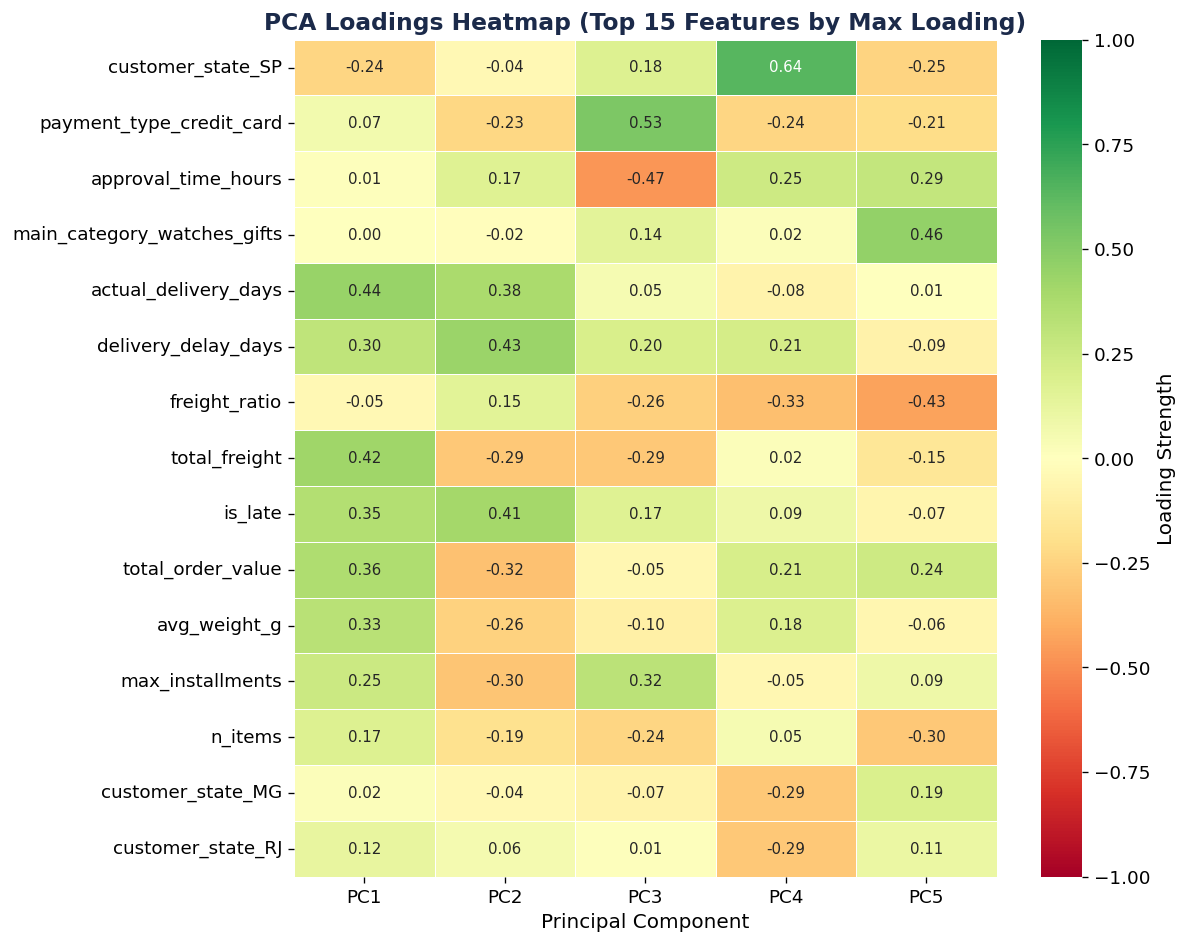

In [16]:
# Heatmap of loadings for top 15 features
top_features = loadings.abs().max(axis=1).sort_values(ascending=False).head(15).index
loadings_top = loadings.loc[top_features]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(loadings_top, ax=ax, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, cbar_kws={'label': 'Loading Strength'})
ax.set_title('PCA Loadings Heatmap (Top 15 Features by Max Loading)',
             color=NAVY, fontweight='bold', fontsize=14)
ax.set_xlabel('Principal Component')
plt.tight_layout()
plt.show()


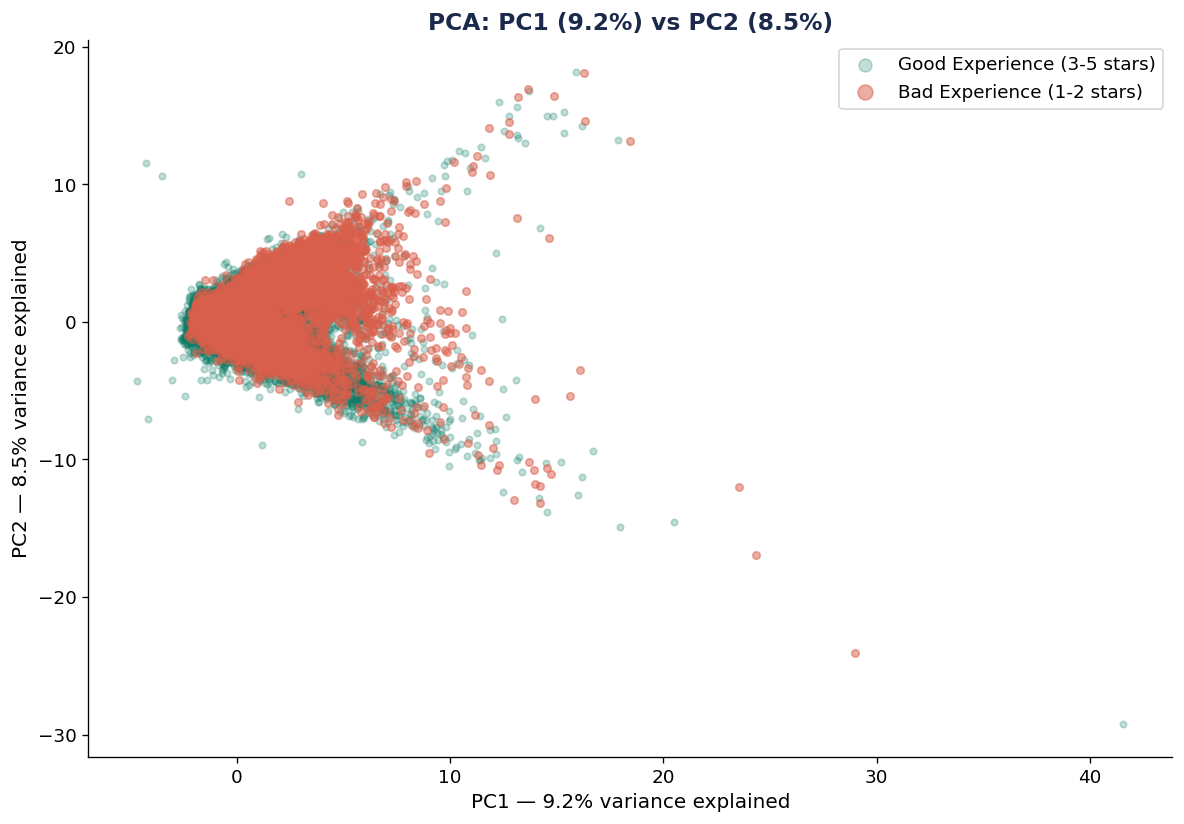

In [17]:
# PC1 vs PC2 scatter coloured by bad_experience
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_pca_input)

good_mask = (y == 0).values
bad_mask  = (y == 1).values

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_2d[good_mask, 0], X_2d[good_mask, 1],
           alpha=0.25, s=15, color=TEAL, label='Good Experience (3-5 stars)')
ax.scatter(X_2d[bad_mask,  0], X_2d[bad_mask,  1],
           alpha=0.5,  s=20, color=CORAL, label='Bad Experience (1-2 stars)')

ev1 = pca_2d.explained_variance_ratio_[0] * 100
ev2 = pca_2d.explained_variance_ratio_[1] * 100
ax.set_title(f'PCA: PC1 ({ev1:.1f}%) vs PC2 ({ev2:.1f}%)',
             color=NAVY, fontweight='bold')
ax.set_xlabel(f'PC1 — {ev1:.1f}% variance explained')
ax.set_ylabel(f'PC2 — {ev2:.1f}% variance explained')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 8: Final Reduced Feature Set</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Selecting interpretable features for modelling</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">Selection Strategy</strong><br>
<span style="color: #333;">
We combine two approaches:<br>
1. <strong>Top PCA loaders</strong> — features that drive the principal components<br>
2. <strong>Top scorecard features</strong> from Session 2 — features most correlated with bad_experience<br>
The union of these two lists, plus key dummy columns, forms the final feature set.
</span>
</div>

In [18]:
# ── Top PCA loaders from first 3 components ──
n_pcs_select = min(3, N_COMPONENTS)
top_pca_features = set()
for i in range(n_pcs_select):
    pc = f'PC{i+1}'
    top6 = loadings[pc].abs().sort_values(ascending=False).head(6).index.tolist()
    top_pca_features.update(top6)

# ── Top direct correlates of bad_experience (from Session 2 scorecard) ──
top_direct_features = [
    'delivery_delay_days', 'actual_delivery_days', 'is_late',
    'freight_ratio', 'approval_time_hours', 'total_order_value',
    'max_installments', 'n_items', 'avg_weight_g', 'purchase_hour',
]
top_direct_features = [f for f in top_direct_features if f in X_filtered2.columns]

# ── Dummy columns for key categoricals ──
dummy_prefixes = [cat + '_' for cat in categorical_cols]
dummy_cols = [c for c in X_filtered2.columns
              if any(c.startswith(p) for p in dummy_prefixes)]

# ── Union and deduplicate ──
combined = list(top_pca_features) + top_direct_features + dummy_cols
final_features = list(dict.fromkeys(
    [f for f in combined if f in X_filtered2.columns]
))

print(f"Features from PCA loadings    : {len(top_pca_features)}")
print(f"Features from direct scorecard: {len(top_direct_features)}")
print(f"Dummy columns included        : {len(dummy_cols)}")
print(f"Final feature set size        : {len(final_features)}")
print(f"\nFinal features list:")
for i, f in enumerate(final_features):
    print(f"  {i+1:>3}. {f}")


Features from PCA loadings    : 11
Features from direct scorecard: 10
Dummy columns included        : 13
Final feature set size        : 24

Final features list:
    1. avg_weight_g
    2. actual_delivery_days
    3. total_order_value
    4. freight_ratio
    5. total_freight
    6. payment_type_credit_card
    7. is_late
    8. n_items
    9. approval_time_hours
   10. max_installments
   11. delivery_delay_days
   12. purchase_hour
   13. main_category_bed_bath_table
   14. main_category_computers_accessories
   15. main_category_furniture_decor
   16. main_category_health_beauty
   17. main_category_housewares
   18. main_category_sports_leisure
   19. main_category_watches_gifts
   20. customer_state_MG
   21. customer_state_PR
   22. customer_state_RJ
   23. customer_state_RS
   24. customer_state_SP


Feature Reduction Pipeline Summary
  Starting features (after encoding) : 117
  After NZV filter                   : 28
  After correlation filter           : 26
  Final selected for modelling       : 24
  Total reduction                    : 79.5%


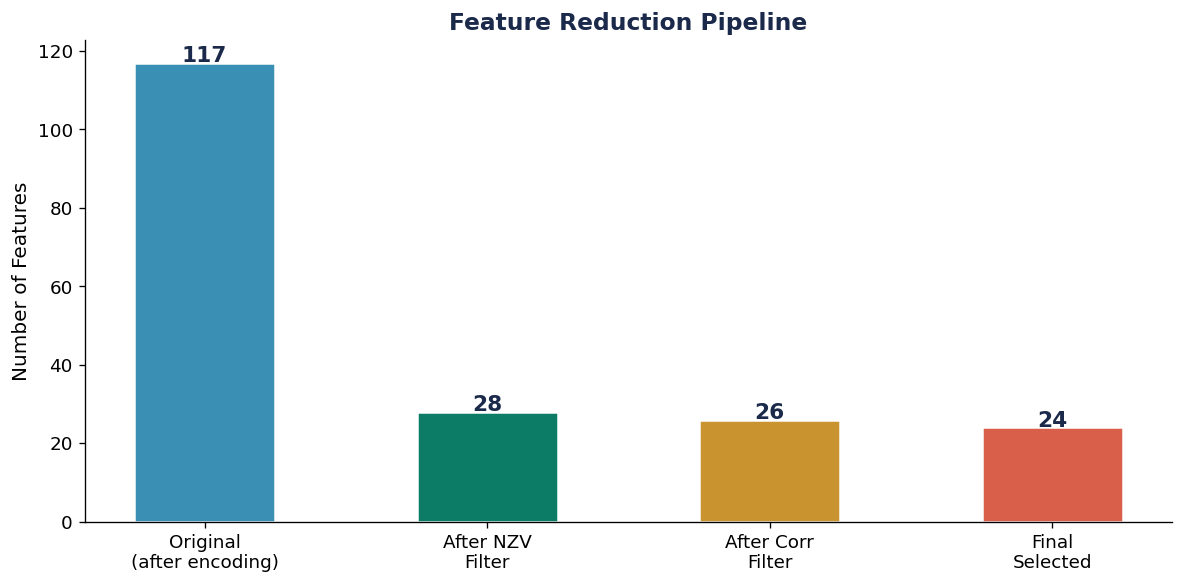

In [19]:
# Pipeline summary
print("Feature Reduction Pipeline Summary")
print("=" * 55)
print(f"  Starting features (after encoding) : {X_scaled.shape[1]}")
print(f"  After NZV filter                   : {X_filtered.shape[1]}")
print(f"  After correlation filter           : {X_filtered2.shape[1]}")
print(f"  Final selected for modelling       : {len(final_features)}")
reduction_pct = (1 - len(final_features) / X_scaled.shape[1]) * 100
print(f"  Total reduction                    : {reduction_pct:.1f}%")

# Visualise pipeline
stages = ['Original\n(after encoding)', 'After NZV\nFilter',
          'After Corr\nFilter', 'Final\nSelected']
counts = [X_scaled.shape[1], X_filtered.shape[1],
          X_filtered2.shape[1], len(final_features)]

fig, ax = plt.subplots(figsize=(10, 5))
colors = [BLUE, TEAL, GOLD, CORAL]
bars = ax.bar(stages, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Feature Reduction Pipeline', color=NAVY, fontweight='bold', fontsize=14)
ax.set_ylabel('Number of Features')
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            str(val), ha='center', fontsize=13, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 9: Save Modelling-Ready Dataset</h2>
</div>

In [20]:
X_final = X_filtered2[final_features].copy()
X_final[target_col] = y.values

out_path = os.path.join(DATA_DIR, 'olist_model_ready.csv')
X_final.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Shape   : {X_final.shape[0]:,} rows x {X_final.shape[1]} columns")
print(f"Features: {X_final.shape[1] - 1} (excluding target)")
print(f"Target  : bad_experience  (rate = {X_final[target_col].mean():.2%})")
print(f"\nAll columns:")
for i, col in enumerate(X_final.columns):
    flag = ' <- TARGET' if col == target_col else ''
    print(f"  {i+1:>3}. {col}{flag}")


Saved: C:\Users\DevA\OneDrive\Desktop\All in one - Desktop Files\MBA\Q8\AI ML\Dataset 3\olist_model_ready.csv
Shape   : 96,478 rows x 25 columns
Features: 24 (excluding target)
Target  : bad_experience  (rate = 12.72%)

All columns:
    1. avg_weight_g
    2. actual_delivery_days
    3. total_order_value
    4. freight_ratio
    5. total_freight
    6. payment_type_credit_card
    7. is_late
    8. n_items
    9. approval_time_hours
   10. max_installments
   11. delivery_delay_days
   12. purchase_hour
   13. main_category_bed_bath_table
   14. main_category_computers_accessories
   15. main_category_furniture_decor
   16. main_category_health_beauty
   17. main_category_housewares
   18. main_category_sports_leisure
   19. main_category_watches_gifts
   20. customer_state_MG
   21. customer_state_PR
   22. customer_state_RJ
   23. customer_state_RS
   24. customer_state_SP
   25. bad_experience <- TARGET


<div style="background: linear-gradient(90deg, #E0F4EF, #FDF6E8); border-left: 5px solid #0D7C66; border-right: 5px solid #C9932F; padding: 16px 20px; border-radius: 6px; margin: 20px 0;">
<strong style="color: #1B2A4A;">Notebook 3 Complete - What We Achieved</strong>
<ul style="color: #333; font-size: 1.05em; line-height: 1.8; margin-top: 8px;">
<li>Built a clean <strong>modelling matrix</strong> — encoded, imputed, and standardised.</li>
<li>Removed <strong>near-zero variance features</strong> that add noise without signal.</li>
<li>Removed <strong>highly correlated redundant features</strong> using a 0.90 pairwise threshold.</li>
<li>Checked <strong>VIF</strong> to confirm no severe multicollinearity in numeric features.</li>
<li>Ran <strong>PCA</strong> and identified how many components capture 80% / 90% of variance.</li>
<li>Interpreted PCA loadings — latent structure reflects delivery quality, order economics, and timing.</li>
<li>Selected a <strong>final feature set</strong> combining PCA signals and direct scorecard correlates.</li>
<li>Saved <strong>olist_model_ready.csv</strong> — ready for Session 4 modelling.</li>
</ul>
</div>

**Next: Notebook 4 — Models to Decisions (Logistic Regression, XGBoost, SHAP, Business Rules)**
